# Credit Card Fraud Detection using XGBoost

**Goal:** Build an XGBoost model to detect fraudulent credit card transactions.

**Key Challenge:** The dataset is highly imbalanced — fraud transactions make up less than 1% of all transactions. Because of this, accuracy alone is not a good metric. We use Precision, Recall, F1-Score, and AUPRC instead.

### Step 1: Import Libraries

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc,
    average_precision_score,
    roc_auc_score
)

### Step 2: Load the Dataset

In [51]:
df = pd.read_csv("data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [52]:
# Dataset info — check for nulls and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [53]:
# Check class distribution
print("Class distribution:")
print(df["Class"].value_counts())
print(f"\nFraud percentage: {df['Class'].mean() * 100:.4f}%")

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


### Step 3: Split Features and Target

In [54]:
X = df.drop("Class", axis=1)  # input features
y = df["Class"]               # target label (0 = normal, 1 = fraud)

### Step 4: Scale the Data

V1–V28 are already PCA-transformed. We only scale `Time` and `Amount`.

In [55]:
scaler = StandardScaler()

X["Amount"] = scaler.fit_transform(X[["Amount"]])
X["Time"]   = scaler.fit_transform(X[["Time"]])

### Step 5: Train/Test Split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps the same fraud ratio in both splits
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)

Training set size: (227845, 30)
Test set size:     (56962, 30)


In [57]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

# Train on original data — NOT X_train_res
xgb_model.fit(X_train, y_train)
print("Model training complete.")

scale_pos_weight: 577.29
Model training complete.


### Step 8: Make Predictions

In [58]:
y_pred = xgb_model.predict(X_test)

y_scores = xgb_model.predict_proba(X_test)[:, 1]

### Step 9: Evaluation

#### Classification Report

In [59]:
print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.78      0.84      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



#### Confusion Matrix

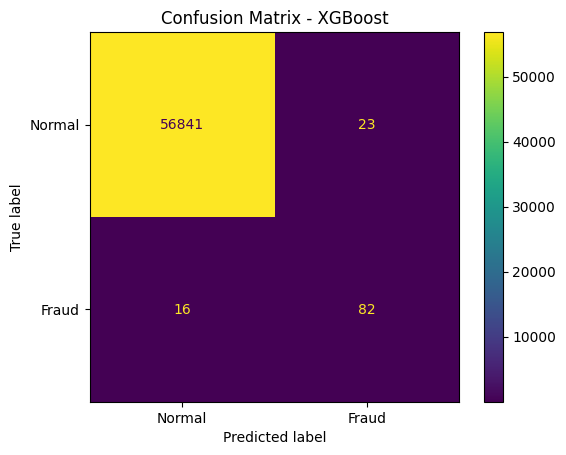

In [60]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
disp.plot()
plt.title("Confusion Matrix - XGBoost")
plt.show()

#### Precision-Recall Curve and AUPRC

AUPRC:                   0.8650
Average Precision Score: 0.8652


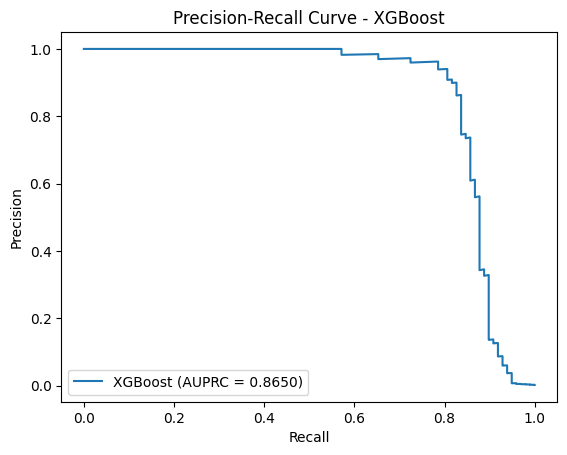

In [61]:
precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)
avg_precision = average_precision_score(y_test, y_scores)

print(f"AUPRC:                   {pr_auc:.4f}")
print(f"Average Precision Score: {avg_precision:.4f}")

plt.figure()
plt.plot(recall, precision, label=f"XGBoost (AUPRC = {pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")
plt.legend()
plt.show()

#### ROC Curve and AUC

ROC-AUC: 0.9747


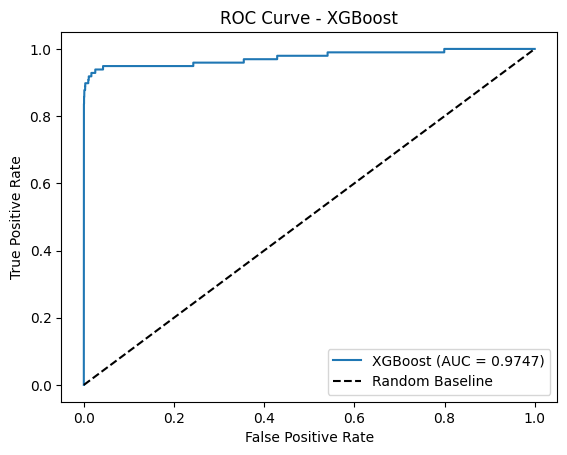

In [62]:
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

print(f"ROC-AUC: {roc_auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

#### Feature Importance

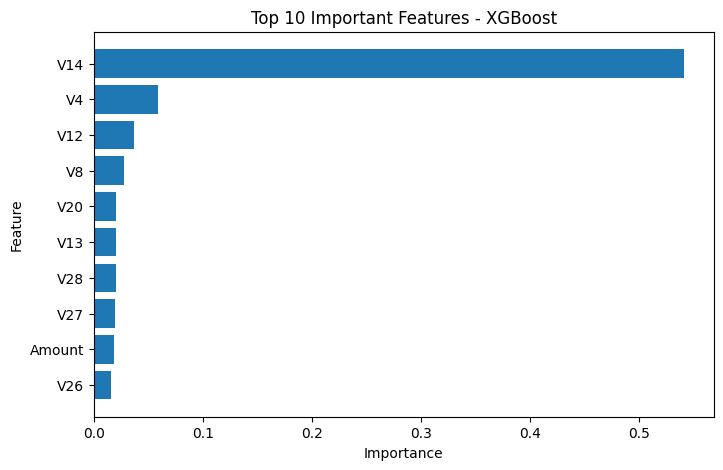

Feature  Importance
    V14    0.541591
     V4    0.058893
    V12    0.037239
     V8    0.027474
    V20    0.020618
    V13    0.020454
    V28    0.020320
    V27    0.019192
 Amount    0.018828
    V26    0.016101


In [63]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - XGBoost")
plt.gca().invert_yaxis()
plt.show()

print(feature_importance.head(10).to_string(index=False))

#### Print Final Metrics Summary (copy these for the report)

In [64]:
from sklearn.metrics import precision_score, recall_score, f1_score

p  = precision_score(y_test, y_pred)
r  = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 40)
print("XGBoost Final Metrics Summary")
print("=" * 40)
print(f"Precision:  {p:.4f}")
print(f"Recall:     {r:.4f}")
print(f"F1-Score:   {f1:.4f}")
print(f"AUPRC:      {pr_auc:.4f}")
print(f"ROC-AUC:    {roc_auc:.4f}")
print("=" * 40)

XGBoost Final Metrics Summary
Precision:  0.7810
Recall:     0.8367
F1-Score:   0.8079
AUPRC:      0.8650
ROC-AUC:    0.9747


### Conclusion for XGBoost

The XGBoost model was trained on the original imbalanced dataset without SMOTE. Instead, the scale_pos_weight parameter was set to the ratio of normal to fraud samples (~577), allowing XGBoost to handle the class imbalance natively through its loss function. The model was evaluated using Precision, Recall, F1-Score, AUPRC, and ROC-AUC, which are more informative metrics than accuracy for imbalanced classification tasks.